# 01 — Cleaning and integration (Deliverable A)

Cleans the trip, weather, events and test files with one set of shared functions, joins them on one clock, builds the features, and exports the A8 tables to `data/processed/`.

| ID | Where in this notebook |
|---|---|
| A1 Cleaning log | Step 12 (re-saved with test rows in Step 22) |
| A2 Time & key standardization | Steps 4–6 (trips), 10–11 (weather, events), Step 13 (summary for all tables) |
| A3 Join map | Step 14 |
| A4 Join audit | Step 16 |
| A5 Join proof | Step 17 |
| A6 Feature table | Step 18 |
| A7 Integrity checks | Steps 8, 10, 11, 19, 20, 22 (PASS/FAIL output) |
| A8 Master tables + data dictionary | Steps 19 and 22 → `master_train.csv`, `master_test.csv`, `data_dictionary_master.csv` |


### Step 1 — Imports, paths and settings

In [140]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
from datetime import datetime

pd.set_option("display.width", 160)
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
RAW_DIR = ROOT / "data" / "raw"
OUT_DIR = ROOT / "data" / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)
import re


print(ROOT)
LOCAL_TZ = "Africa/Addis_Ababa"
LOG = []

c:\Users\hp\flow_code


### Step 2 — Common functions used by all three tables

In [141]:
CANONICAL_ZONES = ["Arat Kilo", "Ayat", "Bole", "CMC", "Gerji", "Kazanchis",
                   "Kolfe", "Lideta", "Megenagna", "Merkato", "Piassa", "Sarbet"]
ZONE_MAP = {z.lower(): z for z in CANONICAL_ZONES} | {
    "piazza": "Piassa", "mercato": "Merkato", "c.m.c": "CMC", "bole rd": "Bole",
    "kolfe keranio": "Kolfe", "megenaga": "Megenagna", "kazanches": "Kazanchis",
}
CITYWIDE = "ALL"
CITYWIDE_ALIASES = {"citywide", "city wide", "city-wide", "city", "all", "all zones", "allzones"}


def clean_label(s: pd.Series) -> pd.Series:
    """Trim spaces and lower-case text."""
    return s.astype(str).str.strip().str.replace(r"\s+", " ", regex=True).str.lower()


def normalize_zone(s: pd.Series, allow_citywide=False, allow_multi=False) -> pd.Series:
    """Map raw zone names to the 12 standard zones."""
    def map_one(label):
        label = label.strip()
        if allow_citywide and label in CITYWIDE_ALIASES:
            return CITYWIDE
        return ZONE_MAP.get(label)

    def map_cell(text):
        zones = [map_one(part) for part in text.split("&")]
        if None in zones:
            return None
        return "|".join(zones)

    key = clean_label(s).str.replace(r"\s*\(.*?\)", "", regex=True)
    if not allow_multi and key.str.contains("&").any():
        raise ValueError(f"Multi-zone labels not allowed: {sorted(s[key.str.contains('&')].unique())}")
    out = key.apply(map_cell)
    unknown = sorted(s[out.isna()].unique())
    if unknown:
        raise ValueError(f"Unmapped zone labels: {unknown}")
    return out


def expand_zones(df: pd.DataFrame, col="zone") -> pd.DataFrame:
    """Split multi-zone and citywide rows into one row per zone."""
    df = df.copy()
    df["is_citywide"] = (df[col] == CITYWIDE).astype(int)
    df["is_multi_zone"] = df[col].str.contains("|", regex=False).astype(int)
    df[col] = df[col].apply(lambda z: CANONICAL_ZONES if z == CITYWIDE else z.split("|"))
    return df.explode(col, ignore_index=True)



def value_map_table(raw: pd.Series, clean: pd.Series) -> pd.DataFrame:
    """Show raw values next to their cleaned values."""
    t = pd.DataFrame({"raw_value": raw.map(repr), "clean_value": clean})
    return t.value_counts().rename("rows").reset_index().sort_values(["clean_value", "raw_value"], ignore_index=True)


def ts_pattern(s: pd.Series) -> pd.Series:
    """Turn a timestamp into its format pattern."""
    return (s.astype(str).str.replace(r"\d", "9", regex=True)
             .str.replace(r"^[A-Z][a-z]{2} ", "Mon ", regex=True))


def format_table(s: pd.Series, formats: dict) -> pd.DataFrame:
    """Count rows for each timestamp format."""
    p = ts_pattern(s)
    t = p.value_counts().rename("rows").to_frame()
    t["pct"] = (t["rows"] / len(s) * 100).round(2)
    t["format"] = [formats.get(k, ("UNKNOWN",))[0] for k in t.index]
    t["source_clock"] = [formats.get(k, (None, "?"))[1] for k in t.index]
    t["example"] = [s[p == k].iloc[0] for k in t.index]
    return t


def parse_timestamps(s: pd.Series, formats: dict) -> pd.Series:
    """Parse every timestamp format and convert to Addis Ababa time."""
    p = ts_pattern(s)
    unknown = set(p.unique()) - set(formats)
    if unknown:
        raise ValueError(f"Unknown timestamp formats: {unknown}")
    out = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
    for pattern, (fmt, source_tz) in formats.items():
        m = p == pattern
        if not m.any():
            continue
        t = pd.to_datetime(s[m], format=fmt)
        if t.dt.tz is None and source_tz != LOCAL_TZ:
            t = t.dt.tz_localize(source_tz)
        if t.dt.tz is not None:
            t = t.dt.tz_convert(LOCAL_TZ).dt.tz_localize(None)
        out[m] = t
    if out.isna().any():
        raise ValueError(f"{int(out.isna().sum())} timestamps failed to parse")
    return out


def to_number(s: pd.Series) -> pd.Series:
    """Convert text like 'approx 34000' or '2,039' to a number."""
    cleaned = s.astype("string").str.lower().str.replace(r"approx\.?|~|,|\s", "", regex=True)
    return pd.to_numeric(cleaned.replace("", pd.NA), errors="raise").astype(float)


def replace_sentinels(df: pd.DataFrame, cols, sentinels=(-1, -9999)) -> pd.DataFrame:
    """Replace placeholder codes like -1 with NaN."""
    df = df.copy()
    for c in cols:
        if c in df:
            df[c] = df[c].mask(df[c].isin(sentinels))
    return df


def dedupe(df: pd.DataFrame, key, prefer=None) -> pd.DataFrame:
    """Keep one row per key, preferring the most complete row."""
    d = df.copy()
    d["_nn"], d["_pos"] = d.notna().sum(axis=1), np.arange(len(d))
    prefer = prefer or []
    d = d.sort_values(list(key) + prefer + ["_nn", "_pos"],
                      ascending=[True] * (len(key) + len(prefer)) + [False, True])
    return d.drop_duplicates(key, keep="first").drop(columns=["_nn", "_pos"]).sort_index()


def split_conflicts(df: pd.DataFrame, key, target: str):
    """Separate duplicate keys whose rows disagree on the target."""
    n_values = df.groupby(key)[target].transform(lambda s: s.dropna().nunique())
    conflict = n_values > 1
    return df[~conflict], df[conflict]


def fit_group_median(df: pd.DataFrame, col: str, levels) -> dict:
    """Learn group medians from the training data."""
    stats = {"levels": [list(l) for l in levels], "global": float(df[col].median())}
    for i, lvl in enumerate(levels):
        med = df.groupby(list(lvl))[col].median()
        stats[str(i)] = {"|".join(map(str, k if isinstance(k, tuple) else (k,))): float(v) for k, v in med.items()}
    return stats


def impute_group_median(df: pd.DataFrame, col: str, stats: dict, flag: str) -> pd.DataFrame:
    """Fill missing values with group medians and add a flag column."""
    df = df.copy()
    miss = df[col].isna()
    df[flag] = miss.astype(int)
    fill = pd.Series(np.nan, index=df.index)
    for i, lvl in enumerate(stats["levels"]):
        key = df[lvl].astype(str).agg("|".join, axis=1)
        fill = fill.fillna(key.map(stats[str(i)]))
    df.loc[miss, col] = fill.fillna(stats["global"])[miss].round(1)
    return df


def log_issue(file, n_total, column, issue, n, fix, why):
    """Add one issue to the cleaning log."""
    LOG.append({"file": file, "column(s)": column, "issue_type": issue, "rows_affected": int(n),
                "pct_rows": round(100 * n / n_total, 2), "fix_applied": fix, "why": why})


def run_checks(name: str, checks: dict) -> bool:
    """Print PASS or FAIL for each check."""
    print(f"--- {name}")
    for label, ok in checks.items():
        print(f"{'PASS' if ok else 'FAIL'}  {label}")
    return all(bool(v) for v in checks.values())


def profile(df: pd.DataFrame) -> pd.DataFrame:
    """Show nulls, unique values and min/max per column."""
    num = df.apply(lambda c: pd.to_numeric(c, errors="coerce"))
    return pd.DataFrame({"nulls": df.isna().sum(), "null_pct": (df.isna().mean() * 100).round(2),
                         "n_unique": df.nunique(), "min": num.min(), "max": num.max()})

### Step 3 — Load and profile the ride demand data

In [142]:
TRIPS_FILE = "ride_demand_train.csv"
raw_trips = pd.read_csv(RAW_DIR / TRIPS_FILE, dtype=str)
print(raw_trips.shape)
profile(raw_trips)

(85460, 7)


,nulls,null_pct,n_unique,min,max
record_id,0,0.00,85460,NaN,NaN
zone,0,0.00,55,NaN,NaN
pickup_hour,0,0.00,20550,NaN,NaN
trips,845,0.99,231,-1.0,640.0
avg_fare_birr,1277,1.49,1637,195.3,371.6
avg_wait_min,0,0.00,59,-1.0,7.0
active_drivers,0,0.00,142,2.0,208.0


### Step 4 — A2(a) Standardise zone names (trips)

In [143]:
print("before:", raw_trips["zone"].nunique(), "labels")
zone_table = value_map_table(raw_trips["zone"], normalize_zone(raw_trips["zone"]))
print("after:", zone_table["clean_value"].nunique(), "labels ->", sorted(zone_table["clean_value"].unique()))
print(zone_table.to_string())

before: 55 labels
after: 12 labels -> ['Arat Kilo', 'Ayat', 'Bole', 'CMC', 'Gerji', 'Kazanchis', 'Kolfe', 'Lideta', 'Megenagna', 'Merkato', 'Piassa', 'Sarbet']
          raw_value clean_value  rows
0       'ARAT KILO'   Arat Kilo   677
1      'Arat  Kilo'   Arat Kilo   705
2      'Arat Kilo '   Arat Kilo   655
3       'Arat Kilo'   Arat Kilo  4506
4       'arat kilo'   Arat Kilo   729
5            'AYAT'        Ayat   675
6           'Ayat '        Ayat   721
7            'Ayat'        Ayat  3382
8            'ayat'        Ayat   729
9            'BOLE'        Bole   674
10          'Bole '        Bole   710
11        'Bole Rd'        Bole   689
12           'Bole'        Bole  4507
13           'bole'        Bole   689
14          'C.M.C'         CMC   880
15           'CMC '         CMC   945
16            'CMC'         CMC  4559
17            'cmc'         CMC   886
18          'GERJI'       Gerji   915
19         'Gerji '       Gerji   906
20          'Gerji'       Gerji  4523
21  

### Step 5 — A2(b) Detect and parse timestamp formats (trips)

In [144]:
TRIP_FORMATS = {
    "9999-99-99 99:99":          ("%Y-%m-%d %H:%M",      LOCAL_TZ),
    "99/99/9999 99:99":          ("%d/%m/%Y %H:%M",      LOCAL_TZ),
    "9999-99-99T99:99:99+99:99": ("%Y-%m-%dT%H:%M:%S%z", "offset in string"),
}
format_table(raw_trips["pickup_hour"], TRIP_FORMATS)

,rows,pct,format,source_clock,example
pickup_hour,,,,,
9999-99-99 99:99,46886,54.86,%Y-%m-%d %H:%M,Africa/Addis_Ababa,2025-06-26 11:00
99/99/9999 99:99,25764,30.15,%d/%m/%Y %H:%M,Africa/Addis_Ababa,16/08/2025 04:00
9999-99-99T99:99:99+99:99,12810,14.99,%Y-%m-%dT%H:%M:%S%z,offset in string,2025-05-27T23:00:00+03:00


In [145]:
p = ts_pattern(raw_trips["pickup_hour"])
is_slash = p == "99/99/9999 99:99"
f = raw_trips.loc[is_slash, "pickup_hour"].str.split(r"[/ ]", expand=True).astype({0: int, 1: int})
print("slash field 1:", f[0].min(), "-", f[0].max(), "| field 2:", f[1].min(), "-", f[1].max())

zones = normalize_zone(raw_trips["zone"])
iso = pd.DataFrame({"z": zones[~is_slash], "fare": raw_trips["avg_fare_birr"][~is_slash],
                    "t": pd.to_datetime(raw_trips["pickup_hour"][~is_slash].str[:16].str.replace("T", " "))}).dropna()
for name, fmt in [("day-first", "%d/%m/%Y %H:%M"), ("month-first", "%m/%d/%Y %H:%M")]:
    sl = pd.DataFrame({"z": zones[is_slash], "fare": raw_trips["avg_fare_birr"][is_slash],
                       "t": pd.to_datetime(raw_trips["pickup_hour"][is_slash], format=fmt, errors="coerce")}).dropna()
    print(f"{name:12s} matches with ISO twin: {len(sl.merge(iso, on=['z', 't', 'fare']))}")

slash field 1: 1 - 31 | field 2: 1 - 10
day-first    matches with ISO twin: 351
month-first  matches with ISO twin: 27


### Step 6 — A2(c) Check all timestamps are on the same clock (trips)

In [146]:
ts = parse_timestamps(raw_trips["pickup_hour"], TRIP_FORMATS)
print("offsets present:", raw_trips.loc[p.str.contains("T"), "pickup_hour"].str[-6:].value_counts().to_dict())
curve = (pd.DataFrame({"fmt": p, "hour": ts.dt.hour, "trips": pd.to_numeric(raw_trips["trips"])})
           .query("trips >= 0").groupby(["hour", "fmt"])["trips"].mean().unstack().round(1))
print(curve.to_string())
naive, aware = curve["9999-99-99 99:99"], curve["9999-99-99T99:99:99+99:99"]
for lag in (-3, 0, 3):
    print(f"corr(naive shifted {lag:+d}h, +03:00) = {naive.shift(lag).corr(aware):.3f}")

offsets present: {'+03:00': 12810}
fmt   99/99/9999 99:99  9999-99-99 99:99  9999-99-99T99:99:99+99:99
hour                                                               
0                  8.7               8.2                        9.2
1                  6.3               7.0                        6.7
2                  5.7               5.8                        5.7
3                  5.8               5.9                        6.4
4                  8.3               8.1                        8.2
5                 15.5              15.3                       14.6
6                 28.9              28.4                       28.5
7                 42.9              43.3                       42.7
8                 43.5              45.4                       43.2
9                 34.9              35.0                       36.3
10                29.6              30.3                       30.3
11                31.1              31.4                       30.9
12           

### Step 7 — Clean the ride demand data

In [147]:
TRIP_NUM = ["trips", "avg_fare_birr", "avg_wait_min", "active_drivers"]
TRIP_KEY = ["zone", "pickup_hour"]
TRIP_IMPUTE_LEVELS = [["zone", "hour"], ["zone"]]


def fix_x8_inflation(df: pd.DataFrame, threshold: float):
    """Fix trip counts that were multiplied by 8."""
    df = df.copy()
    ratio = df["trips"] / df["active_drivers"]
    m = (ratio > threshold) & (df["trips"] % 8 == 0)
    df.loc[m, "trips"] = df.loc[m, "trips"] / 8
    return df, int(m.sum())


def clean_trips(raw: pd.DataFrame, stats: dict | None = None, is_train=True, log=True):
    """Run every cleaning step on the ride demand data."""
    n = len(raw)
    L = (lambda *a: log_issue(TRIPS_FILE, n, *a)) if log else (lambda *a: None)
    d = raw.copy()

    key = clean_label(d["zone"])
    canon = {z.lower() for z in CANONICAL_ZONES}
    zone = normalize_zone(d["zone"])
    L("zone", "Inconsistent case / extra whitespace", ((d["zone"] != zone) & key.isin(canon)).sum(),
      "trim, collapse spaces, case-insensitive match", "Same zone would otherwise count as different groups")
    L("zone", "Aliases / misspellings (Piazza, Mercato, C.M.C, Bole Rd, ...)", (~key.isin(canon)).sum(),
      "alias map to canonical label; unknown labels raise", "All tables must share the same 12 zone keys")
    d["zone"] = zone

    p = ts_pattern(d["pickup_hour"])
    L("pickup_hour", "Mixed timestamp formats (DD/MM/YYYY, ISO with offset)", (p != "9999-99-99 99:99").sum(),
      "explicit format per pattern (day-first verified)", "Guessing can swap day/month and break hourly joins")
    L("pickup_hour", "Mixed clocks: +03:00 offset vs naive", p.str.contains("T").sum(),
      "convert to Africa/Addis_Ababa, drop tz", "All tables must share one clock for the joins")
    d["pickup_hour"] = parse_timestamps(d["pickup_hour"], TRIP_FORMATS)

    for c in TRIP_NUM:
        if c in d:
            d[c] = pd.to_numeric(d[c], errors="raise")
    if "trips" in d:
        L("trips", "Sentinel -1", (d["trips"] == -1).sum(), "set to NaN (missing target)", "-1 is a no-data code, not a count")
    L("avg_wait_min", "Sentinel -1", (d["avg_wait_min"] == -1).sum(), "set to NaN, then imputed", "A negative wait is impossible")
    d = replace_sentinels(d, ["trips", "avg_wait_min"], sentinels=(-1,))

    threshold = stats["ratio_threshold"] if stats else 3.0
    n_drop_outlier = 0
    if "trips" in d:
        d, n_x8 = fix_x8_inflation(d, threshold)
        L("trips", "Outlier: values inflated x8 (trips/driver >= 4)", n_x8,
          "divide by 8 where ratio > 3 and trips % 8 == 0", "Physically implausible; /8 restores the normal ratio")
        bad = d["trips"] / d["active_drivers"] > threshold
        n_drop_outlier = int(bad.sum())
        L("trips", "Outlier: implausible ratio, not a multiple of 8", n_drop_outlier, "row dropped", "True value unrecoverable")
        d = d[~bad]

    n_conflict = 0
    if is_train:
        d, conflicts = split_conflicts(d, TRIP_KEY, "trips")
        n_conflict = len(conflicts)
        conflicts.sort_values(TRIP_KEY).to_csv(OUT_DIR / "trip_conflicts.csv", index=False)
        L("zone, pickup_hour", "Duplicate zone-hours with different trip counts", n_conflict,
          "removed from train, saved to trip_conflicts.csv", "No evidence which count is correct")

    before = len(d)
    d = dedupe(d, TRIP_KEY)
    n_dup = before - len(d)
    L("zone, pickup_hour", "Duplicate zone-hours with the same or one missing trip count", n_dup,
      "keep 1 row per zone-hour (most complete, then first)", "Double-counts demand; breaks many-to-one joins")

    n_target = 0
    if is_train:
        n_target = int(d["trips"].isna().sum())
        L("trips", "Missing target (blank or -1)", n_target, "row dropped from train", "Imputing the target invents labels")
        d = d[d["trips"].notna()].copy()
        d["trips"] = d["trips"].astype(int)

    d["hour"] = d["pickup_hour"].dt.hour
    if stats is None:
        stats = {"ratio_threshold": threshold,
                 "avg_fare_birr": fit_group_median(d, "avg_fare_birr", TRIP_IMPUTE_LEVELS),
                 "avg_wait_min": fit_group_median(d, "avg_wait_min", TRIP_IMPUTE_LEVELS)}
    L("avg_fare_birr", "Missing values", raw["avg_fare_birr"].isna().sum(),
      "train median by zone x hour (+ fare_imputed flag)", "Fare follows a zone/hour pattern")
    d = impute_group_median(d, "avg_fare_birr", stats["avg_fare_birr"], "fare_imputed")
    d = impute_group_median(d, "avg_wait_min", stats["avg_wait_min"], "wait_imputed")
    L("avg_wait_min", "Spike at 1.2 min (platform floor) - checked", (d["avg_wait_min"] == 1.2).sum(),
      "kept unchanged", "Plausible minimum wait, mostly at night")

    d = d.drop(columns="hour").sort_values(["pickup_hour", "zone"]).reset_index(drop=True)
    d.attrs["n_dropped"] = n_drop_outlier + n_conflict + n_dup + n_target
    return d, stats


trips_clean, trips_stats = clean_trips(raw_trips)
print(raw_trips.shape, "->", trips_clean.shape)
trips_clean.head()

(85460, 7) -> (82742, 9)


,record_id,zone,pickup_hour,trips,avg_fare_birr,avg_wait_min,active_drivers,fare_imputed,wait_imputed
0,R-070502,Arat Kilo,2025-01-01,5,240.4,1.9,5,0,0
1,R-058374,Bole,2025-01-01,8,322.8,3.0,6,0,0
2,R-073684,CMC,2025-01-01,4,289.2,1.6,5,0,0
3,R-016735,Gerji,2025-01-01,2,290.2,1.5,3,0,0
4,R-002178,Kazanchis,2025-01-01,0,248.5,1.2,2,0,0


### Step 8 — A7 Integrity checks: cleaned trips

In [148]:
def validate_trips(d: pd.DataFrame, n_raw: int, is_train=True) -> bool:
    """Check the cleaned ride demand data."""
    num = [c for c in TRIP_NUM if c in d]
    return run_checks("trips", {
        "one row per zone-hour": not d.duplicated(TRIP_KEY).any(),
        "record_id unique": d["record_id"].is_unique,
        "only the 12 canonical zones": set(d["zone"]) == set(CANONICAL_ZONES),
        "timestamps naive EAT, on the hour": d["pickup_hour"].dt.tz is None and (d["pickup_hour"].dt.minute == 0).all(),
        "timestamps in 2025-01-01 .. 2025-10-31": d["pickup_hour"].between("2025-01-01", "2025-10-31 23:00").all(),
        "no missing values": not d.isna().any().any(),
        "no negative / sentinel values": not (d[num] < 0).any().any(),
        "trips/driver <= 3 (no x8 inflation)": "trips" not in d or (d["trips"] / d["active_drivers"] <= 3).all(),
        "trips is a non-negative integer": "trips" not in d or (d["trips"].dtype.kind == "i" and (d["trips"] >= 0).all()),
        "rows reconcile: raw - dropped = clean": len(d) == n_raw - d.attrs["n_dropped"],
    })

assert validate_trips(trips_clean, len(raw_trips))

--- trips
PASS  one row per zone-hour
PASS  record_id unique
PASS  only the 12 canonical zones
PASS  timestamps naive EAT, on the hour
PASS  timestamps in 2025-01-01 .. 2025-10-31
PASS  no missing values
PASS  no negative / sentinel values
PASS  trips/driver <= 3 (no x8 inflation)
PASS  trips is a non-negative integer
PASS  rows reconcile: raw - dropped = clean


In [149]:
conflicts = pd.read_csv(OUT_DIR / "trip_conflicts.csv", parse_dates=["pickup_hour"])
gap = conflicts.groupby(TRIP_KEY)["trips"].agg(lambda s: s.max() - s.min())
print(f"conflicting zone-hours: {len(gap)} ({len(conflicts)} rows)")
print("trip difference:", gap.value_counts().sort_index().to_dict())
print("by zone:", conflicts.drop_duplicates(TRIP_KEY)["zone"].value_counts().to_dict())
print("by hour:", conflicts.drop_duplicates(TRIP_KEY)["pickup_hour"].dt.hour.value_counts().sort_index().to_dict())


conflicting zone-hours: 362 (724 rows)
trip difference: {1.0: 122, 2.0: 125, 3.0: 115}
by zone: {'Merkato': 40, 'Bole': 38, 'Kazanchis': 35, 'Kolfe': 34, 'Piassa': 30, 'Megenagna': 29, 'Arat Kilo': 28, 'Gerji': 28, 'CMC': 27, 'Sarbet': 26, 'Lideta': 24, 'Ayat': 23}
by hour: {0: 18, 1: 14, 2: 13, 3: 16, 4: 17, 5: 13, 6: 13, 7: 15, 8: 14, 9: 13, 10: 10, 11: 23, 12: 16, 13: 18, 14: 18, 15: 15, 16: 18, 17: 14, 18: 12, 19: 11, 20: 13, 21: 15, 22: 12, 23: 21}


### Step 9 — Save the cleaned trips (`trips_clean.csv`)

In [150]:
TRIP_COLS = ["record_id", "zone", "pickup_hour", "trips", "avg_fare_birr", "avg_wait_min",
             "active_drivers", "fare_imputed", "wait_imputed"]
out = trips_clean[TRIP_COLS].copy()
out["pickup_hour"] = out["pickup_hour"].dt.strftime("%Y-%m-%d %H:%M:%S")
out.to_csv(OUT_DIR / "trips_clean.csv", index=False)
(OUT_DIR / "train_stats.json").write_text(json.dumps(trips_stats, indent=1))
print("saved trips_clean.csv", out.shape)

saved trips_clean.csv (82742, 9)


### Step 10 — Clean the weather data

In [151]:
WEATHER_FILE = "weather_hourly.csv"
WEATHER_FORMATS = {
    "9999-99-99T99:99:99Z": ("%Y-%m-%dT%H:%M:%SZ", "UTC"),
    "99/99/9999 99:99":     ("%d/%m/%Y %H:%M",     "UTC"),
}
WEATHER_NUM = ["temp_c", "rain_mm", "humidity_pct", "wind_kmh"]
WEATHER_SMOOTH = ["temp_c", "humidity_pct", "wind_kmh"]
WEATHER_IMPUTE_LEVELS = [["month", "hour"], ["hour"]]
TRAIN_END = "2025-10-31 23:00"
GAP_LIMIT = 3


def interpolate_short_gaps(s: pd.Series, limit: int) -> pd.Series:
    """Fill only gaps of at most `limit` hours by time interpolation."""
    na = s.isna()
    run_len = na.groupby((na != na.shift()).cumsum()).transform("sum")
    filled = s.interpolate(method="time", limit_area="inside")
    return s.where(~(na & (run_len <= limit)), filled)


def clean_weather(raw: pd.DataFrame, stats: dict | None = None, log=True):
    """Run every cleaning step on the weather data."""
    n = len(raw)
    L = (lambda *a: log_issue(WEATHER_FILE, n, *a)) if log else (lambda *a: None)
    d = raw.copy()

    p = ts_pattern(d["timestamp"])
    L("timestamp", "Mixed timestamp formats (ISO Z, DD/MM/YYYY)", (p == "99/99/9999 99:99").sum(),
      "explicit format per pattern (day-first verified)", "Guessing can swap day/month and break hourly joins")
    L("timestamp", "UTC clock (both Z and slash rows)", len(d),
      "convert UTC to Africa/Addis_Ababa (+3h), drop tz", "All tables must share one clock for the joins")
    d["timestamp"] = parse_timestamps(d["timestamp"], WEATHER_FORMATS)

    for c in WEATHER_NUM:
        d[c] = pd.to_numeric(d[c], errors="raise")
    L("rain_mm", "Sentinel -9999", (d["rain_mm"] == -9999).sum(), "set to NaN, then filled", "-9999 is a no-data code")
    d = replace_sentinels(d, ["rain_mm"], sentinels=(-9999,))

    f = d["temp_c"] > 40
    L("temp_c", "Unit error: Fahrenheit values (54-77)", f.sum(), "(F - 32) * 5/9 where temp_c > 40",
      "Addis is never above 40 C; converted values fit the normal range")
    d.loc[f, "temp_c"] = ((d.loc[f, "temp_c"] - 32) * 5 / 9).round(1)

    d["is_forecast"] = (clean_label(d["data_type"]) == "forecast").astype(int)
    before = len(d)
    d = dedupe(d, ["timestamp"], prefer=["is_forecast"])
    L("timestamp", "Duplicate hours (observed vs forecast / same hour twice)", before - len(d),
      "keep 1 row per hour: observed first, then most complete", "Weather join must be many-to-one")
    d = d.drop(columns="data_type").sort_values("timestamp").set_index("timestamp").asfreq("h")

    gap = d["wind_kmh"].isna() & d["temp_c"].isna() & d["is_forecast"].isna()
    L("timestamp", "Missing hours (no weather row)", gap.sum(), "added to a full hourly index, then filled below",
      "Hidden gaps would make lag features use the wrong hours")
    for c in ["temp_c", "humidity_pct"]:
        L(c, "Missing values", raw[c].isna().sum(), "interpolate gaps <= 3h, else train median by month x hour",
          "Temperature/humidity change smoothly hour to hour")
    d["weather_row_missing"] = gap.astype(int)
    d["weather_imputed"] = d[WEATHER_NUM].isna().any(axis=1).astype(int)
    d["is_forecast"] = d["is_forecast"].fillna(0).astype(int)

    for c in WEATHER_SMOOTH:
        d[c] = interpolate_short_gaps(d[c], GAP_LIMIT)
    d = d.reset_index()
    d["month"], d["hour"] = d["timestamp"].dt.month, d["timestamp"].dt.hour
    if stats is None:
        train = d[d["timestamp"] <= TRAIN_END]
        stats = {c: fit_group_median(train, c, WEATHER_IMPUTE_LEVELS) for c in WEATHER_SMOOTH}
    for c in WEATHER_SMOOTH:
        d = impute_group_median(d, c, stats[c], "_tmp").drop(columns="_tmp")
    d["rain_mm"] = d["rain_mm"].fillna(0)
    return d.drop(columns=["month", "hour"]), stats


raw_weather = pd.read_csv(RAW_DIR / WEATHER_FILE, dtype=str)
weather_clean, weather_stats = clean_weather(raw_weather)
print(raw_weather.shape, "->", weather_clean.shape)


(7538, 6) -> (7656, 8)


In [152]:
def validate_weather(d: pd.DataFrame) -> bool:
    """Check the cleaned weather data."""
    t = d["timestamp"]
    return run_checks("weather", {
        "one row per hour": t.is_unique,
        "continuous hourly index": (t.diff().dropna() == pd.Timedelta("1h")).all(),
        "covers trip range with 3h lookback": t.min() <= pd.Timestamp("2024-12-31 21:00") and t.max() >= pd.Timestamp(TRAIN_END),
        "no missing values": not d.isna().any().any(),
        "temp_c in 0-40": d["temp_c"].between(0, 40).all(),
        "humidity_pct in 0-100": d["humidity_pct"].between(0, 100).all(),
        "rain_mm >= 0": (d["rain_mm"] >= 0).all(),
    })

assert validate_weather(weather_clean)
weather_clean.to_csv(OUT_DIR / "weather_clean.csv", index=False)


--- weather
PASS  one row per hour
PASS  continuous hourly index
PASS  covers trip range with 3h lookback
PASS  no missing values
PASS  temp_c in 0-40
PASS  humidity_pct in 0-100
PASS  rain_mm >= 0


### Step 11 — Clean the events data

In [153]:
EVENTS_FILE = "events_calendar.csv"
EVENT_FORMATS = {
    "9999-99-99 99:99":      ("%Y-%m-%d %H:%M",     LOCAL_TZ),
    "99/99/9999 99:99":      ("%d/%m/%Y %H:%M",     LOCAL_TZ),
    "Mon 99, 9999 99:99 AM": ("%b %d, %Y %I:%M %p", LOCAL_TZ),
    "Mon 99, 9999 99:99 PM": ("%b %d, %Y %I:%M %p", LOCAL_TZ),
}
EVENT_TYPES = ["football_match", "concert", "conference", "exhibition",
               "road_closure", "public_holiday", "sports_run", "school_break"]
NOT_APPLICABLE = {"public_holiday", "road_closure", "school_break"}
EVENT_TRAIN_END = "2025-11-01"
EVENT_COLS = ["event_id", "event_name", "event_type", "venue", "zone", "is_citywide", "is_multi_zone",
              "start_datetime", "end_datetime", "end_imputed", "end_rounded",
              "expected_attendance", "attendance_imputed", "status", "is_cancelled"]


def parse_optional_timestamps(s: pd.Series, formats: dict) -> pd.Series:
    """Parse timestamps that may be blank; blanks stay NaT."""
    out = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
    m = s.notna()
    out[m] = parse_timestamps(s[m], formats)
    return out


def event_type_key(s: pd.Series) -> pd.Series:
    """Turn raw event types into snake_case keys."""
    return clean_label(s).str.replace(" ", "_")


def clean_events(raw: pd.DataFrame, stats: dict | None = None, log=True):
    """Run every cleaning step on the events data; cancelled events are kept and flagged."""
    n = len(raw)
    L = (lambda *a: log_issue(EVENTS_FILE, n, *a)) if log else (lambda *a: None)
    d = raw.apply(lambda s: s.str.strip()).replace("", pd.NA)

    key = event_type_key(d["event_type"])
    unknown = set(key) - set(EVENT_TYPES)
    if unknown:
        raise ValueError(f"Unmapped event types: {unknown}")
    L("event_type", "Inconsistent spellings (case, spaces, underscores)", (d["event_type"] != key).sum(),
      f"lower-case, spaces -> '_', {len(EVENT_TYPES)} types", "One label per type for event features")
    d["event_type"] = key

    zone = normalize_zone(d["zone"], allow_citywide=True, allow_multi=True)
    multi = zone.str.contains("|", regex=False)
    L("zone", "Sub-city in brackets / case / aliases", ((zone != d["zone"]) & (zone != CITYWIDE) & ~multi).sum(),
      "normalize_zone (same map as trips)", "All tables must share the same 12 zone keys")
    L("zone", "Several zones in one cell ('A & B')", multi.sum(),
      "expand_zones: one row per zone, event_id kept", "The event affects each listed zone")
    L("zone", "Citywide labels (Citywide, ALL, All zones, city-wide)", (zone == CITYWIDE).sum(),
      "expand_zones: one row for each of the 12 zones, is_citywide=1", "Citywide is not a 13th zone")
    d["zone"] = zone

    ps, pe = ts_pattern(d["start_datetime"]), ts_pattern(d["end_datetime"])
    iso = "9999-99-99 99:99"
    L("start_datetime, end_datetime", "Mixed timestamp formats (ISO, DD/MM/YYYY, 'Mon DD, YYYY HH:MM AM/PM')",
      ((ps != iso) | (d["end_datetime"].notna() & (pe != iso))).sum(),
      "parse_timestamps with explicit formats (day-first verified), local EAT",
      "Guessing can swap day/month and misplace event windows")
    d["start_datetime"] = parse_optional_timestamps(d["start_datetime"], EVENT_FORMATS)
    d["end_datetime"] = parse_optional_timestamps(d["end_datetime"], EVENT_FORMATS)

    r = d["end_datetime"].notna() & (d["end_datetime"].dt.minute != 0)
    d["end_rounded"] = r.astype(int)
    d.loc[r, "end_datetime"] = d.loc[r, "end_datetime"].dt.ceil("h")
    L("end_datetime", "End at 23:59 instead of a full hour", r.sum(),
      "rounded up to the next full hour (exclusive end)", "Event windows must cover whole zone-hours")

    status = clean_label(d["status"])
    L("status", "Inconsistent case / trailing spaces", (d["status"] != status).sum(),
      "trim + lower-case -> confirmed / cancelled", "One label per status")
    d["status"] = status
    d["is_cancelled"] = (status == "cancelled").astype(int)
    L("status", "Cancelled events", d["is_cancelled"].sum(),
      "kept in the file with is_cancelled=1; excluded from joins and medians", "A cancelled event draws no crowd")

    before = d["event_id"].tolist()
    d = dedupe(d, [c for c in d.columns if c != "event_id"], prefer=["event_id"])
    removed = sorted(set(before) - set(d["event_id"]))
    L("event_id", "Duplicate events re-issued with new IDs", len(removed),
      "dedupe on every column except event_id; original EVT-0xxx kept (" + ", ".join(removed) + ")",
      "The same event would be counted twice")

    invalid = d["end_datetime"].notna() & (d["end_datetime"] <= d["start_datetime"])
    missing = d["end_datetime"].isna()
    d.loc[invalid, "end_datetime"] = pd.NaT
    d["duration_h"] = (d["end_datetime"] - d["start_datetime"]) / pd.Timedelta(hours=1)
    d["attendance_num"] = to_number(d["expected_attendance"])
    basis = d[(d["is_cancelled"] == 0) & (d["start_datetime"] < EVENT_TRAIN_END)]
    if stats is None:
        stats = {"duration_h": fit_group_median(basis, "duration_h", [["event_type"]]),
                 "expected_attendance": fit_group_median(basis[~basis["event_type"].isin(NOT_APPLICABLE)],
                                                         "attendance_num", [["event_type"]])}
    d = impute_group_median(d, "duration_h", stats["duration_h"], "end_imputed")
    d["end_datetime"] = d["start_datetime"] + pd.to_timedelta(d["duration_h"], unit="h")
    L("end_datetime", "Missing end time", missing.sum(),
      "start + train median duration for the event type (end_imputed=1)", "The event window needs an end")
    if invalid.any():
        L("end_datetime", "End before start", invalid.sum(),
          "treated as missing and filled the same way (" + ", ".join(d.loc[invalid[invalid].index.intersection(d.index), "event_id"]) + ")",
          "An event cannot end before it starts")

    att = d["expected_attendance"]
    L("expected_attendance", "Stored as text ('approx 34000', '2,039')",
      (att.notna() & ~att.str.fullmatch(r"\d+", na=False)).sum(), "to_number: removed 'approx' and commas",
      "Attendance must be numeric for features")
    d["expected_attendance"] = d.pop("attendance_num")
    na_type = d["event_type"].isin(NOT_APPLICABLE)
    miss_att = d["expected_attendance"].isna()
    d.loc[miss_att & na_type, "expected_attendance"] = 0
    L("expected_attendance", "Missing where attendance does not apply", (miss_att & na_type).sum(),
      "set to 0 (holidays, road closures, school breaks)", "These events have no ticketed crowd")
    d = impute_group_median(d, "expected_attendance", stats["expected_attendance"], "attendance_imputed")
    d["expected_attendance"] = d["expected_attendance"].round().astype(int)
    L("expected_attendance", "Missing where attendance applies", d["attendance_imputed"].sum(),
      "train median for the event type (attendance_imputed=1)", "Keeps the attendance feature usable")

    miss_venue = d["venue"].isna()
    if not set(d.loc[miss_venue, "event_type"]) <= NOT_APPLICABLE:
        raise ValueError("venue missing on an event type that needs one")
    d["venue"] = d["venue"].fillna("none")
    L("venue", "Missing venue (checked)", miss_venue.sum(), "filled 'none'",
      "Only missing for holidays, road closures, school breaks")

    d = expand_zones(d)
    d = d[EVENT_COLS].sort_values(["start_datetime", "event_id", "zone"]).reset_index(drop=True)
    return d, stats


In [154]:
raw_events = pd.read_csv(RAW_DIR / EVENTS_FILE, dtype=str)
print(format_table(raw_events["start_datetime"], EVENT_FORMATS).iloc[:, :4])

slash = ts_pattern(raw_events["start_datetime"]) == "99/99/9999 99:99"
f = raw_events.loc[slash, "start_datetime"].str.split(r"[/ ]", expand=True).astype({0: int, 1: int})
print("slash field 1:", f[0].min(), "-", f[0].max(), "| field 2:", f[1].min(), "-", f[1].max())

print("\nevent_type before -> after:")
print(value_map_table(raw_events["event_type"], event_type_key(raw_events["event_type"].str.strip())).to_string())

events_clean, events_stats = clean_events(raw_events)
print(f"\n{len(raw_events)} raw rows -> {events_clean['event_id'].nunique()} unique events "
      f"({int(events_clean.drop_duplicates('event_id')['is_cancelled'].sum())} cancelled) -> {len(events_clean)} event-zone rows")
events_clean.head()


                       rows    pct              format        source_clock
start_datetime                                                            
9999-99-99 99:99         79  47.88      %Y-%m-%d %H:%M  Africa/Addis_Ababa
99/99/9999 99:99         50  30.30      %d/%m/%Y %H:%M  Africa/Addis_Ababa
Mon 99, 9999 99:99 PM    21  12.73  %b %d, %Y %I:%M %p  Africa/Addis_Ababa
Mon 99, 9999 99:99 AM    15   9.09  %b %d, %Y %I:%M %p  Africa/Addis_Ababa
slash field 1: 1 - 31 | field 2: 1 - 11

event_type before -> after:
            raw_value     clean_value  rows
0           'CONCERT'         concert    14
1           'Concert'         concert     6
2           'concert'         concert     8
3        'Conference'      conference    19
4        'conference'      conference    19
5        'Exhibition'      exhibition     3
6        'exhibition'      exhibition     4
7    'Football Match'  football_match    15
8   'football match '  football_match    14
9    'football_match'  football_match    

,event_id,event_name,event_type,venue,zone,is_citywide,is_multi_zone,start_datetime,end_datetime,end_imputed,end_rounded,expected_attendance,attendance_imputed,status,is_cancelled
0,EVT-0001,Genna (Ethiopian Christmas),public_holiday,none,Arat Kilo,1,0,2025-01-07,2025-01-08,0,1,0,0,confirmed,0
1,EVT-0001,Genna (Ethiopian Christmas),public_holiday,none,Ayat,1,0,2025-01-07,2025-01-08,0,1,0,0,confirmed,0
2,EVT-0001,Genna (Ethiopian Christmas),public_holiday,none,Bole,1,0,2025-01-07,2025-01-08,0,1,0,0,confirmed,0
3,EVT-0001,Genna (Ethiopian Christmas),public_holiday,none,CMC,1,0,2025-01-07,2025-01-08,0,1,0,0,confirmed,0
4,EVT-0001,Genna (Ethiopian Christmas),public_holiday,none,Gerji,1,0,2025-01-07,2025-01-08,0,1,0,0,confirmed,0


In [155]:
def validate_events(d: pd.DataFrame) -> bool:
    """Check the cleaned events data."""
    return run_checks("events", {
        "one row per event and zone": not d.duplicated(["event_id", "zone"]).any(),
        "only the 12 canonical zones": set(d["zone"]) <= set(CANONICAL_ZONES),
        "only the 8 event types": set(d["event_type"]) <= set(EVENT_TYPES),
        "status is confirmed or cancelled": set(d["status"]) <= {"confirmed", "cancelled"},
        "no missing values": not d.isna().any().any(),
        "end after start": (d["end_datetime"] > d["start_datetime"]).all(),
        "start and end on the hour": ((d["start_datetime"].dt.minute == 0) & (d["end_datetime"].dt.minute == 0)).all(),
        "attendance is a non-negative integer": d["expected_attendance"].dtype.kind == "i" and (d["expected_attendance"] >= 0).all(),
        "citywide events cover all 12 zones": (d[d["is_citywide"] == 1].groupby("event_id")["zone"].nunique() == 12).all(),
    })

assert validate_events(events_clean)
out = events_clean.copy()
for c in ["start_datetime", "end_datetime"]:
    out[c] = out[c].dt.strftime("%Y-%m-%d %H:%M:%S")
out.to_csv(OUT_DIR / "events_clean.csv", index=False)
print("saved events_clean.csv", out.shape)


--- events
PASS  one row per event and zone
PASS  only the 12 canonical zones
PASS  only the 8 event types
PASS  status is confirmed or cancelled
PASS  no missing values
PASS  end after start
PASS  start and end on the hour
PASS  attendance is a non-negative integer
PASS  citywide events cover all 12 zones
saved events_clean.csv (328, 15)


### Step 12 — A1 Cleaning log

In [156]:
cleaning_log = pd.DataFrame(LOG)
cleaning_log.index = range(1, len(cleaning_log) + 1)
cleaning_log.to_csv(OUT_DIR / "cleaning_log.csv", index_label="#")
cleaning_log

,file,column(s),issue_type,rows_affected,pct_rows,fix_applied,why
1,ride_demand_train.csv,zone,Inconsistent case / extra whitespace,27533,32.22,"trim, collapse spaces, case-insensitive match",Same zone would otherwise count as different g...
2,ride_demand_train.csv,zone,"Aliases / misspellings (Piazza, Mercato, C.M.C...",4858,5.68,alias map to canonical label; unknown labels r...,All tables must share the same 12 zone keys
3,ride_demand_train.csv,pickup_hour,"Mixed timestamp formats (DD/MM/YYYY, ISO with ...",38574,45.14,explicit format per pattern (day-first verified),Guessing can swap day/month and break hourly j...
4,ride_demand_train.csv,pickup_hour,Mixed clocks: +03:00 offset vs naive,12810,14.99,"convert to Africa/Addis_Ababa, drop tz",All tables must share one clock for the joins
5,ride_demand_train.csv,trips,Sentinel -1,681,0.80,set to NaN (missing target),"-1 is a no-data code, not a count"
6,ride_demand_train.csv,avg_wait_min,Sentinel -1,1707,2.00,"set to NaN, then imputed",A negative wait is impossible
7,ride_demand_train.csv,trips,Outlier: values inflated x8 (trips/driver >= 4),124,0.15,divide by 8 where ratio > 3 and trips % 8 == 0,Physically implausible; /8 restores the normal...
8,ride_demand_train.csv,trips,"Outlier: implausible ratio, not a multiple of 8",1,0.00,row dropped,True value unrecoverable
9,ride_demand_train.csv,"zone, pickup_hour",Duplicate zone-hours with different trip counts,724,0.85,"removed from train, saved to trip_conflicts.csv",No evidence which count is correct
10,ride_demand_train.csv,"zone, pickup_hour",Duplicate zone-hours with the same or one miss...,483,0.57,"keep 1 row per zone-hour (most complete, then ...",Double-counts demand; breaks many-to-one joins


### Step 13 — A2 Time & key standardization (summary for all three tables)

#### A2(a) Zone and event_type labels before and after

In [157]:
events_zone_table = value_map_table(raw_events["zone"], normalize_zone(raw_events["zone"].str.strip(),
                                                                       allow_citywide=True, allow_multi=True))
print(f"events zone: {raw_events['zone'].nunique()} raw labels -> 12 zones (+ 'ALL' and 'A|B', expanded to one row per zone)")
print(events_zone_table.to_string())
print("\nweather: no zone column (one citywide station) -> joined to every zone on the hour")

after = {"trips": sorted(trips_clean["zone"].unique()), "events": sorted(events_clean["zone"].unique())}
for name, zones in after.items():
    print(f"{name:7s} after cleaning: {len(zones)} labels, identical to CANONICAL_ZONES: {zones == sorted(CANONICAL_ZONES)}")
print("event_type after cleaning:", sorted(events_clean["event_type"].unique()))

events zone: 28 raw labels -> 12 zones (+ 'ALL' and 'A|B', expanded to one row per zone)
                  raw_value          clean_value  rows
0                     'ALL'                  ALL     3
1               'All zones'                  ALL     2
2                'Citywide'                  ALL     9
3               'city-wide'                  ALL     1
4               'arat kilo'            Arat Kilo     1
5      'Arat Kilo & SARBET'     Arat Kilo|Sarbet     1
6                    'AYAT'                 Ayat     2
7                    'Ayat'                 Ayat     1
8           'Ayat & Lideta'          Ayat|Lideta     1
9                    'BOLE'                 Bole     5
10    'Bole (Bole subcity)'                 Bole    10
11                   'Bole'                 Bole    29
12                    'CMC'                  CMC     1
13                    'cmc'                  CMC     2
14                  'Gerji'                Gerji     1
15              'KAZANCHIS'    

#### A2(b) Timestamp formats parsed per table, and the day-first check

In [158]:
for name, s, formats in [("trips", raw_trips["pickup_hour"], TRIP_FORMATS),
                         ("weather", raw_weather["timestamp"], WEATHER_FORMATS),
                         ("events start", raw_events["start_datetime"], EVENT_FORMATS),
                         ("events end", raw_events["end_datetime"].dropna(), EVENT_FORMATS)]:
    print(f"--- {name}")
    print(format_table(s, formats).iloc[:, :4].to_string())


def day_first_check(s: pd.Series) -> dict:
    """For DD/MM/YYYY strings: field ranges and how many fail if read month-first."""
    slash = s[ts_pattern(s) == "99/99/9999 99:99"]
    parts = slash.str.split(r"[/ ]", expand=True)
    month_first = pd.to_datetime(slash, format="%m/%d/%Y %H:%M", errors="coerce")
    return {"rows": len(slash), "field1_max": int(parts[0].astype(int).max()),
            "field2_max": int(parts[1].astype(int).max()), "fail_if_month_first": int(month_first.isna().sum())}


print("\nday-first check:")
print(pd.DataFrame({name: day_first_check(s) for name, s in [("trips", raw_trips["pickup_hour"]),
                                                            ("weather", raw_weather["timestamp"]),
                                                            ("events start", raw_events["start_datetime"]),
                                                            ("events end", raw_events["end_datetime"].dropna())]}).T)

--- trips
                            rows    pct               format        source_clock
pickup_hour                                                                     
9999-99-99 99:99           46886  54.86       %Y-%m-%d %H:%M  Africa/Addis_Ababa
99/99/9999 99:99           25764  30.15       %d/%m/%Y %H:%M  Africa/Addis_Ababa
9999-99-99T99:99:99+99:99  12810  14.99  %Y-%m-%dT%H:%M:%S%z    offset in string
--- weather
                      rows    pct              format source_clock
timestamp                                                         
9999-99-99T99:99:99Z  6806  90.29  %Y-%m-%dT%H:%M:%SZ          UTC
99/99/9999 99:99       732   9.71      %d/%m/%Y %H:%M          UTC
--- events start
                       rows    pct              format        source_clock
start_datetime                                                            
9999-99-99 99:99         79  47.88      %Y-%m-%d %H:%M  Africa/Addis_Ababa
99/99/9999 99:99         50  30.30      %d/%m/%Y %H:%M  Africa/

#### A2(c) Which clock each table is on

In [159]:
w_raw = raw_weather.copy()
w_raw["temp_c"] = pd.to_numeric(w_raw["temp_c"])
w_raw["temp"] = np.where(w_raw["temp_c"] > 40, (w_raw["temp_c"] - 32) * 5 / 9, w_raw["temp_c"])
is_z = w_raw["timestamp"].str.endswith("Z")
w_raw["t"] = pd.NaT
w_raw.loc[is_z, "t"] = pd.to_datetime(w_raw.loc[is_z, "timestamp"], format="%Y-%m-%dT%H:%M:%SZ")
w_raw.loc[~is_z, "t"] = pd.to_datetime(w_raw.loc[~is_z, "timestamp"], format="%d/%m/%Y %H:%M")
w_raw["t"] = pd.to_datetime(w_raw["t"])
z_series = w_raw[is_z].groupby("t")["temp"].mean().asfreq("h").interpolate(limit_area="inside")
slash = w_raw[~is_z].dropna(subset=["temp"])
fit = {k: round(float(np.nanmedian(np.abs(slash["temp"].values - z_series.reindex(slash["t"] + pd.Timedelta(hours=k)).values))), 2)
       for k in range(-4, 5)}
print("weather: slash rows vs Z series, median |temp diff| by shift (h):", fit)
print("weather: mean temp peaks at", int(weather_clean.groupby(weather_clean["timestamp"].dt.hour)["temp_c"].mean().idxmax()),
      ":00 Addis time after the +3h conversion")

ev_once = events_clean.drop_duplicates("event_id")
print("events: start hours by type (Addis time):",
      ev_once.groupby("event_type")["start_datetime"].apply(lambda s: sorted(s.dt.hour.unique())).to_dict())

clock_proof = pd.DataFrame([
    ("trips", "Addis local (EAT, UTC+3)",
     "ISO rows carry +03:00; naive rows share the same hourly demand curve (corr 0.998 at 0h vs ~0.25 at ±3h) — Step 6",
     "offset rows tz-converted to EAT; naive rows unchanged"),
    ("weather", "UTC (both 'Z' and DD/MM rows)",
     f"slash rows fit the Z series best at shift 0 ({fit[0]} °C vs {fit[-3]} at -3h); temp peaks 15:00 after +3h",
     "all rows +3h to EAT, tz dropped"),
    ("events", "Addis local (EAT)",
     "matches start 15/18/19h, concerts 19–20h, conferences 08h, holidays 00h; demand peaks around these hours (fig08)",
     "none (already local)"),
], columns=["table", "raw clock", "evidence", "conversion applied"])
clock_proof

weather: slash rows vs Z series, median |temp diff| by shift (h): {-4: 3.6, -3: 2.7, -2: 1.8, -1: 1.0, 0: 0.55, 1: 1.1, 2: 1.8, 3: 2.6, 4: 3.3}
weather: mean temp peaks at 15 :00 Addis time after the +3h conversion
events: start hours by type (Addis time): {'concert': [np.int32(19), np.int32(20)], 'conference': [np.int32(8)], 'exhibition': [np.int32(10)], 'football_match': [np.int32(15), np.int32(18), np.int32(19)], 'public_holiday': [np.int32(0)], 'road_closure': [np.int32(2), np.int32(3), np.int32(5), np.int32(7), np.int32(8), np.int32(9), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(18)], 'school_break': [np.int32(0)], 'sports_run': [np.int32(6)]}


,table,raw clock,evidence,conversion applied
0,trips,"Addis local (EAT, UTC+3)",ISO rows carry +03:00; naive rows share the sa...,offset rows tz-converted to EAT; naive rows un...
1,weather,UTC (both 'Z' and DD/MM rows),slash rows fit the Z series best at shift 0 (0...,"all rows +3h to EAT, tz dropped"
2,events,Addis local (EAT),"matches start 15/18/19h, concerts 19–20h, conf...",none (already local)


### Step 14 — A3 Join map

| Join | Left table | Right table | Key | Join type | Cardinality |
|---|---|---|---|---|---|
| 1 | cleaned trips (one row per zone-hour) | cleaned weather (one row per hour) | `pickup_hour` = `timestamp` | left | many-to-one (12 zone-hours → 1 weather hour) |
| 2 | result of join 1 | event windows (one row per event × zone × hour) | `zone` + `pickup_hour` inside [start − 2h, end + 2h) | left, interval | many-to-many, aggregated to one row per zone-hour before joining |
| 3 | result of join 2 | public holidays / school breaks | `zone` + `pickup_hour` inside [start, end) | left, interval | many-to-one after de-duplication |

**Why trips is the left table:** a zone-hour is the unit we forecast, so every trip row must survive every join, and weather or events must never add or drop rows.

**Event window rule:** from **2 hours before the start** to **2 hours after the end**. fig08 shows demand rising from −2h (people travelling in) and a second peak just after the end (people leaving; matches last ~2h, concerts ~4h).

Holidays and school breaks are whole-day or multi-week calendar periods, so they become calendar flags, not event windows.

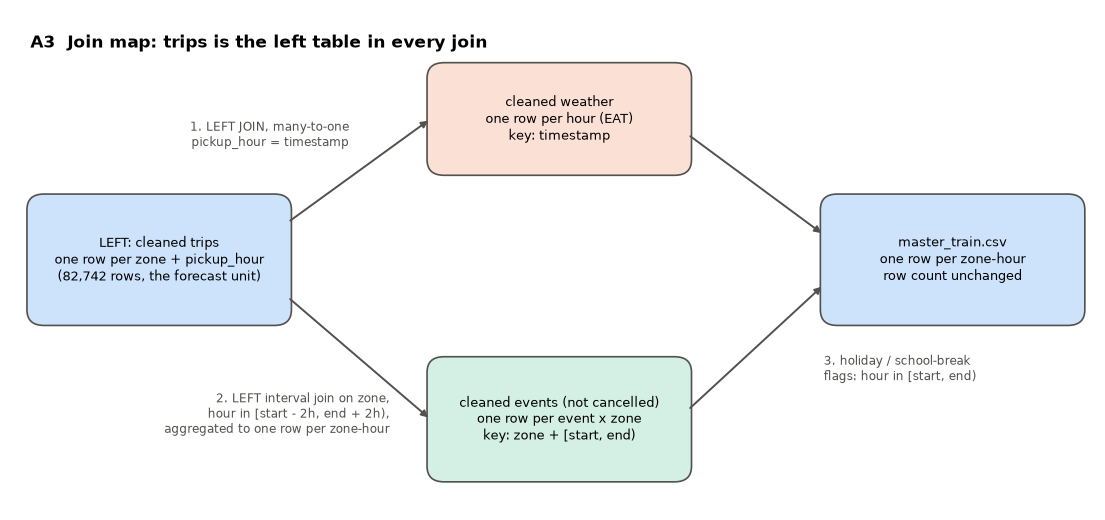

In [160]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 6.5))
ax.set_xlim(0, 16)
ax.set_ylim(0, 8)
ax.axis("off")
boxes = {
    "trips": (0.3, 3.0, 3.8, 2.0, "#cde2fb", f"LEFT: cleaned trips\none row per zone + pickup_hour\n({len(trips_clean):,} rows, the forecast unit)"),
    "weather": (6.2, 5.4, 3.8, 1.7, "#fbe0d6", "cleaned weather\none row per hour (EAT)\nkey: timestamp"),
    "events": (6.2, 0.5, 3.8, 1.9, "#d4f0e5", "cleaned events (not cancelled)\none row per event x zone\nkey: zone + [start, end)"),
    "out": (12.0, 3.0, 3.8, 2.0, "#cde2fb", "master_train.csv\none row per zone-hour\nrow count unchanged"),
}
for x, y, w_, h, color, text in boxes.values():
    ax.add_patch(FancyBboxPatch((x, y), w_, h, boxstyle="round,pad=0.05,rounding_size=0.25",
                                facecolor=color, edgecolor="#52514e", linewidth=1.2))
    ax.text(x + w_ / 2, y + h / 2, text, ha="center", va="center", fontsize=9.5)
arrow = dict(arrowstyle="-|>", color="#52514e", lw=1.4)
ax.annotate("", xy=(6.2, 6.25), xytext=(4.1, 4.6), arrowprops=arrow)
ax.annotate("", xy=(6.2, 1.45), xytext=(4.1, 3.4), arrowprops=arrow)
ax.annotate("", xy=(12.0, 4.4), xytext=(10.0, 6.0), arrowprops=arrow)
ax.annotate("", xy=(12.0, 3.6), xytext=(10.0, 1.6), arrowprops=arrow)
ax.text(5.0, 5.75, "1. LEFT JOIN, many-to-one\npickup_hour = timestamp", ha="right", va="bottom", fontsize=8.5, color="#52514e")
ax.text(5.6, 1.9, "2. LEFT interval join on zone,\nhour in [start - 2h, end + 2h),\naggregated to one row per zone-hour", ha="right", va="top", fontsize=8.5, color="#52514e")
ax.text(12.0, 2.5, "3. holiday / school-break\nflags: hour in [start, end)", ha="left", va="top", fontsize=8.5, color="#52514e")
ax.text(0.3, 7.6, "A3  Join map: trips is the left table in every join", fontsize=12, fontweight="bold", va="top")
fig.savefig(ROOT / "figures" / "a3_join_map.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 15 — Integrate: join weather and events, build features

In [161]:
EVENT_WINDOW_BEFORE_H, EVENT_WINDOW_AFTER_H = 2, 2
CALENDAR_EVENT_TYPES = ["public_holiday", "school_break"]
RAIN_BINS = [-0.01, 0, 1, 5, np.inf]


def expand_window(df: pd.DataFrame, before_h: int, after_h: int) -> pd.DataFrame:
    """One row per zone-hour inside each event's window [start - before_h, end + after_h)."""
    parts = []
    for r in df.itertuples():
        hrs = pd.date_range(r.start_datetime.floor("h") - pd.Timedelta(hours=before_h),
                            r.end_datetime.ceil("h") + pd.Timedelta(hours=after_h - 1), freq="h")
        parts.append(pd.DataFrame({"event_id": r.event_id, "event_type": r.event_type, "zone": r.zone,
                                   "pickup_hour": hrs, "attendance": r.expected_attendance}))
    return pd.concat(parts, ignore_index=True)


left = trips_clean.copy()
n_left = len(left)

w = weather_clean.sort_values("timestamp").copy()
w["rain_3h"] = w["rain_mm"].rolling(3, min_periods=1).sum()
w["rain_class"] = pd.cut(w["rain_mm"], RAIN_BINS, labels=False).astype(int)
assert w["timestamp"].is_unique, "duplicate weather hours would multiply trip rows"
joined = left.merge(w.rename(columns={"timestamp": "pickup_hour"}), on="pickup_hour", how="left",
                    validate="many_to_one", indicator="weather_join")
n_after_weather = len(joined)

active = events_clean[events_clean["is_cancelled"] == 0]
local = active[~active["event_type"].isin(CALENDAR_EVENT_TYPES)]
windows = expand_window(local, EVENT_WINDOW_BEFORE_H, EVENT_WINDOW_AFTER_H)
ev = windows.groupby(["zone", "pickup_hour"]).agg(ev_in_window=("event_id", "size"),
                                                   ev_attendance=("attendance", "sum"))
ev["ev_in_window"] = 1
ev = ev.join(pd.crosstab([windows["zone"], windows["pickup_hour"]], windows["event_type"]).clip(upper=1).add_prefix("ev_"))
joined = joined.merge(ev.reset_index(), on=["zone", "pickup_hour"], how="left", validate="one_to_one")
ev_cols = [c for c in joined.columns if c.startswith("ev_")]
joined[ev_cols] = joined[ev_cols].fillna(0).astype(int)
n_after_events = len(joined)

for etype, col in [("public_holiday", "is_holiday"), ("school_break", "is_school_break")]:
    cover = expand_window(active[active["event_type"] == etype], 0, 0)[["zone", "pickup_hour"]].drop_duplicates()
    joined = joined.merge(cover.assign(**{col: 1}), on=["zone", "pickup_hour"], how="left", validate="one_to_one")
    joined[col] = joined[col].fillna(0).astype(int)

joined = joined.sort_values("pickup_hour")
starts = local[["zone", "start_datetime"]].sort_values("start_datetime").rename(columns={"start_datetime": "next_start"})
ends = local[["zone", "end_datetime"]].sort_values("end_datetime").rename(columns={"end_datetime": "last_end"})
joined = pd.merge_asof(joined, starts, left_on="pickup_hour", right_on="next_start", by="zone", direction="forward")
joined = pd.merge_asof(joined, ends, left_on="pickup_hour", right_on="last_end", by="zone", direction="backward")
joined["hours_to_next_event"] = ((joined["next_start"] - joined["pickup_hour"]) / pd.Timedelta(hours=1)).clip(upper=48).fillna(48)
joined["hours_since_event_end"] = ((joined["pickup_hour"] - joined["last_end"]) / pd.Timedelta(hours=1)).clip(upper=48).fillna(48)
joined = joined.drop(columns=["next_start", "last_end"])

t = joined["pickup_hour"]
joined["hour"] = t.dt.hour
joined["dow"] = t.dt.dayofweek
joined["is_weekend"] = (joined["dow"] >= 5).astype(int)
joined["month"] = t.dt.month
joined["days_to_month_end"] = t.dt.days_in_month - t.dt.day
joined["trend_days"] = (t - t.min().normalize()) / pd.Timedelta(days=1)

lag_src = trips_clean[["zone", "pickup_hour", "trips"]]
for days in (14, 21, 28):
    lag = lag_src.assign(pickup_hour=lag_src["pickup_hour"] + pd.Timedelta(days=days)).rename(columns={"trips": f"lag_{days}d"})
    joined = joined.merge(lag, on=["zone", "pickup_hour"], how="left", validate="one_to_one")
joined["lag_mean_14_28d"] = joined[["lag_14d", "lag_21d", "lag_28d"]].mean(axis=1)

joined = joined.sort_values(["pickup_hour", "zone"]).reset_index(drop=True)
print(f"rows: trips {n_left:,} -> +weather {n_after_weather:,} -> +events {n_after_events:,} -> final {len(joined):,}")

rows: trips 82,742 -> +weather 82,742 -> +events 82,742 -> final 82,742


### Step 16 — A4 Join audit

In [162]:
no_weather = joined["weather_row_missing"] == 1
event_hours = joined["ev_in_window"] == 1
join_audit = pd.DataFrame([
    {"join": "trips ← weather (many-to-one on hour)", "rows_before": n_left, "rows_after": n_after_weather,
     "matched_rows": int((joined["weather_join"] == "both").sum()),
     "match_rate_pct": round(100 * (joined["weather_join"] == "both").mean(), 2)},
    {"join": "trips ← event windows (interval, aggregated per zone-hour)", "rows_before": n_after_weather,
     "rows_after": n_after_events, "matched_rows": int(event_hours.sum()),
     "match_rate_pct": round(100 * event_hours.mean(), 2)},
])
print(join_audit.to_string(index=False))
print(f"\nzone-hours whose weather hour had NO original row: {int(no_weather.sum()):,} "
      f"({joined.loc[no_weather, 'pickup_hour'].nunique()} distinct hours) — station gaps in the raw file; "
      f"filled in Step 10 (interpolation <= 3h, else month x hour median) and flagged weather_row_missing=1")
print(f"zone-hours with any estimated weather value: {int(joined['weather_imputed'].sum()):,}")

ev_ids = events_clean.drop_duplicates("event_id").set_index("event_id")
all_windows = pd.concat([expand_window(local, EVENT_WINDOW_BEFORE_H, EVENT_WINDOW_AFTER_H),
                         expand_window(active[active["event_type"].isin(CALENDAR_EVENT_TYPES)], 0, 0)])
hit_ids = set(all_windows.merge(left[["zone", "pickup_hour"]], on=["zone", "pickup_hour"])["event_id"])
period_end = left["pickup_hour"].max()
status = pd.Series("matched >= 1 zone-hour", index=ev_ids.index)
status[ev_ids["is_cancelled"] == 1] = "excluded: cancelled"
status[(ev_ids["is_cancelled"] == 0) & (ev_ids["start_datetime"] > period_end)] = "excluded: after the Jan–Oct trip period (test period)"
status[(status == "matched >= 1 zone-hour") & ~status.index.isin(hit_ids)] = "excluded: no trip rows inside the window"
event_audit = status.value_counts().rename("events").to_frame()
print(f"\n{len(ev_ids)} unique events:")
print(event_audit.to_string())
print(status[status.str.startswith("excluded")].sort_index().to_string())

                                                      join  rows_before  rows_after  matched_rows  match_rate_pct
                     trips ← weather (many-to-one on hour)        82742       82742         82742          100.00
trips ← event windows (interval, aggregated per zone-hour)        82742       82742          1829            2.21

zone-hours whose weather hour had NO original row: 2,154 (186 distinct hours) — station gaps in the raw file; filled in Step 10 (interpolation <= 3h, else month x hour median) and flagged weather_row_missing=1
zone-hours with any estimated weather value: 5,036

159 unique events:
                                                       events
matched >= 1 zone-hour                                    146
excluded: after the Jan–Oct trip period (test period)       7
excluded: cancelled                                         6
event_id
EVT-0020                                  excluded: cancelled
EVT-0042                                  excluded: cance

### Step 17 — A5 Join proof: three zone-hours

In [163]:
SHOW = ["zone", "pickup_hour", "trips", "temp_c", "rain_mm", "rain_3h", "rain_class", "weather_imputed",
        "ev_in_window", "ev_attendance", "hours_to_next_event", "hours_since_event_end", "is_holiday",
        "is_weekend", "lag_14d"]
rain_row = joined[(joined["rain_mm"] > 5) & (joined["weather_imputed"] == 0)].sort_values(["rain_mm", "zone"], ascending=[False, True]).iloc[0]
matches = local[local["event_type"] == "football_match"].sort_values("start_datetime")
match_hours = matches[["zone", "start_datetime"]].rename(columns={"start_datetime": "pickup_hour"})
event_row = joined.merge(match_hours, on=["zone", "pickup_hour"]).iloc[0]
holiday_row = joined[(joined["is_holiday"] == 1) & (joined["hour"] == 12) & (joined["ev_in_window"] == 0)].sort_values(["pickup_hour", "zone"]).iloc[0]

for label, row in [("rain", rain_row), ("event window", event_row), ("public holiday", holiday_row)]:
    z, h = row["zone"], row["pickup_hour"]
    print(f"\n=== {label}: {z} @ {h}")
    print("weather row attached:")
    print(weather_clean[weather_clean["timestamp"] == h].to_string(index=False))
    attached = all_windows[(all_windows["zone"] == z) & (all_windows["pickup_hour"] == h)]["event_id"]
    print("event rows attached:", "none" if attached.empty else "")
    if not attached.empty:
        print(events_clean[events_clean["event_id"].isin(attached) & (events_clean["zone"] == z)]
              [["event_id", "event_name", "event_type", "start_datetime", "end_datetime", "expected_attendance"]].to_string(index=False))
    print("features produced:")
    print(row[SHOW].to_frame().T.to_string(index=False))


=== rain: Arat Kilo @ 2025-05-02 17:00:00
weather row attached:
          timestamp  temp_c  rain_mm  humidity_pct  wind_kmh  is_forecast  weather_row_missing  weather_imputed
2025-05-02 17:00:00    21.5     21.0          76.0       6.1            0                    0                0
event rows attached: none
features produced:
     zone         pickup_hour trips temp_c rain_mm rain_3h rain_class weather_imputed ev_in_window ev_attendance hours_to_next_event hours_since_event_end is_holiday is_weekend lag_14d
Arat Kilo 2025-05-02 17:00:00    96   21.5    21.0    21.8          3               0            0             0                48.0                  48.0          0          0    20.0

=== event window: Kazanchis @ 2025-01-19 15:00:00
weather row attached:
          timestamp  temp_c  rain_mm  humidity_pct  wind_kmh  is_forecast  weather_row_missing  weather_imputed
2025-01-19 15:00:00    23.7      0.0          56.0      14.0            0                    0                0

### Step 18 — A6 Feature engineering table

In [164]:
feature_table = pd.DataFrame([
    ("hour", "pickup_hour.hour", "pickup_hour", "Strong daily demand cycle (peaks 08h / 18h)", "yes"),
    ("dow", "pickup_hour.dayofweek (0=Mon)", "pickup_hour", "Weekday vs weekend patterns differ by zone type", "yes"),
    ("is_weekend", "dow >= 5", "pickup_hour", "Business zones drop ~50% at weekends, Bole rises", "yes"),
    ("month", "pickup_hour.month", "pickup_hour", "Seasonality (rainy season Jun–Sep)", "yes"),
    ("days_to_month_end", "days_in_month - day", "pickup_hour", "Payday proxy: spending rises near month end", "yes"),
    ("trend_days", "days since 1 Jan 2025", "pickup_hour", "Demand grew ~41% Jan→Oct", "yes"),
    ("is_holiday", "zone-hour inside a public_holiday event", "events.event_type, start/end", "Holidays run at ~0.8x a weekday (fig09)", "yes"),
    ("is_school_break", "zone-hour inside a school_break event", "events.event_type, start/end", "Commute pattern changes in school breaks", "yes"),
    ("temp_c", "hourly temperature (°C, EAT)", "weather.temp_c", "Comfort affects walking vs riding", "yes (weather forecast)"),
    ("rain_mm", "rain in the hour", "weather.rain_mm", "Rain raises demand ~1.6x (except Merkato, fig07)", "yes (weather forecast)"),
    ("rain_3h", "sum of rain_mm over the last 3 hours", "weather.rain_mm", "Wet streets keep demand up after rain stops", "yes (weather forecast)"),
    ("rain_class", "0 dry, 1 <=1mm, 2 1–5mm, 3 >5mm", "weather.rain_mm", "Non-linear rain effect by intensity", "yes (weather forecast)"),
    ("humidity_pct / wind_kmh", "hourly values", "weather", "Secondary weather signals", "yes (weather forecast)"),
    ("weather_imputed", "1 if any weather value was estimated", "weather_clean flags", "Lets the model trust estimated weather less", "yes"),
    ("ev_in_window", "1 if zone-hour in [start-2h, end+2h) of any event", "events zone, start/end", "Crowds before and after events (fig08)", "yes (scheduled)"),
    ("ev_attendance", "sum of expected_attendance of events in window", "events.expected_attendance", "Bigger crowds, bigger spikes", "yes (scheduled)"),
    ("ev_<type>", "1 if a <type> event window covers the zone-hour", "events.event_type", "Matches, concerts, conferences peak at different times", "yes (scheduled)"),
    ("hours_to_next_event", "hours until next event start in the zone (cap 48)", "events.start_datetime", "Arrival build-up before start", "yes (scheduled)"),
    ("hours_since_event_end", "hours since last event end in the zone (cap 48)", "events.end_datetime", "Exit surge after the end", "yes (scheduled)"),
    ("lag_14d / lag_21d / lag_28d", "trips same zone & hour 14/21/28 days earlier", "trips", "Recent level of demand for that zone-hour", "yes (horizon <= 14 days)"),
    ("lag_mean_14_28d", "mean of the three lags", "trips", "Smoother recent level, robust to one odd day", "yes (horizon <= 14 days)"),
    ("avg_fare_birr, avg_wait_min, active_drivers", "observed in the same hour", "trips", "NOT used as features", "no"),
], columns=["feature", "formula", "source columns", "why it should help", "known at forecast time?"])
feature_table.to_csv(OUT_DIR / "feature_table.csv", index=False)
feature_table

,feature,formula,source columns,why it should help,known at forecast time?
0,hour,pickup_hour.hour,pickup_hour,Strong daily demand cycle (peaks 08h / 18h),yes
1,dow,pickup_hour.dayofweek (0=Mon),pickup_hour,Weekday vs weekend patterns differ by zone type,yes
2,is_weekend,dow >= 5,pickup_hour,"Business zones drop ~50% at weekends, Bole rises",yes
3,month,pickup_hour.month,pickup_hour,Seasonality (rainy season Jun–Sep),yes
4,days_to_month_end,days_in_month - day,pickup_hour,Payday proxy: spending rises near month end,yes
5,trend_days,days since 1 Jan 2025,pickup_hour,Demand grew ~41% Jan→Oct,yes
6,is_holiday,zone-hour inside a public_holiday event,"events.event_type, start/end",Holidays run at ~0.8x a weekday (fig09),yes
7,is_school_break,zone-hour inside a school_break event,"events.event_type, start/end",Commute pattern changes in school breaks,yes
8,temp_c,"hourly temperature (°C, EAT)",weather.temp_c,Comfort affects walking vs riding,yes (weather forecast)
9,rain_mm,rain in the hour,weather.rain_mm,"Rain raises demand ~1.6x (except Merkato, fig07)",yes (weather forecast)


### Step 19 — A7 Integrity checks and A8 `master_train.csv`

In [165]:
assert run_checks("integration", {
    "row count unchanged by every join": n_left == n_after_weather == n_after_events == len(joined),
    "one row per zone-hour": not joined.duplicated(["zone", "pickup_hour"]).any(),
    "every zone-hour matched a weather hour": (joined["weather_join"] == "both").all(),
    "only the 12 canonical zones": set(joined["zone"]) == set(CANONICAL_ZONES),
    "no missing values outside lag features": not joined.drop(columns=[c for c in joined if c.startswith("lag_")]).isna().any().any(),
    "no cancelled event in any feature": not windows["event_id"].isin(events_clean.loc[events_clean["is_cancelled"] == 1, "event_id"]).any(),
    "weather columns complete": joined[["temp_c", "rain_mm", "humidity_pct", "wind_kmh"]].notna().all().all(),
})
out = joined.drop(columns="weather_join").copy()
out["pickup_hour"] = out["pickup_hour"].dt.strftime("%Y-%m-%d %H:%M:%S")
out.to_csv(OUT_DIR / "master_train.csv", index=False)
print("saved master_train.csv", out.shape)

--- integration
PASS  row count unchanged by every join
PASS  one row per zone-hour
PASS  every zone-hour matched a weather hour
PASS  only the 12 canonical zones
PASS  no missing values outside lag features
PASS  no cancelled event in any feature
PASS  weather columns complete
saved master_train.csv (82742, 40)


### Step 20 — Load and clean the test file (same rules as train)

In [166]:
TEST_FILE = "ride_demand_test.csv"
raw_test = pd.read_csv(RAW_DIR / TEST_FILE, dtype=str)
print(raw_test.shape)
profile(raw_test)

(4032, 3)


,nulls,null_pct,n_unique,min,max
row_id,0,0.0,4032,NaN,NaN
zone,0,0.0,55,NaN,NaN
pickup_hour,0,0.0,949,NaN,NaN


In [167]:
def clean_test(raw: pd.DataFrame) -> pd.DataFrame:
    """Clean test rows with the train zone map and timestamp rules; no row is ever dropped."""
    n = len(raw)
    d = raw.copy()
    key = clean_label(d["zone"])
    canon = {z.lower() for z in CANONICAL_ZONES}
    zone = normalize_zone(d["zone"])
    log_issue(TEST_FILE, n, "zone", "Inconsistent case / extra whitespace", ((d["zone"] != zone) & key.isin(canon)).sum(),
              "same normalize_zone as train", "Test must use the same 12 zone keys as train")
    log_issue(TEST_FILE, n, "zone", "Aliases / misspellings (Piazza, Mercato, C.M.C, Bole Rd, ...)", (~key.isin(canon)).sum(),
              "same alias map as train", "Test must use the same 12 zone keys as train")
    d["zone"] = zone
    p = ts_pattern(d["pickup_hour"])
    log_issue(TEST_FILE, n, "pickup_hour", "Mixed timestamp formats (DD/MM/YYYY, ISO with offset)", (p != "9999-99-99 99:99").sum(),
              "same TRIP_FORMATS as train (day-first verified)", "Must land on the same hourly keys as the features")
    log_issue(TEST_FILE, n, "pickup_hour", "Mixed clocks: +03:00 offset vs naive", p.str.contains("T").sum(),
              "convert to Africa/Addis_Ababa, drop tz", "One clock for every table")
    d["pickup_hour"] = parse_timestamps(d["pickup_hour"], TRIP_FORMATS)
    return d.sort_values(["pickup_hour", "zone"]).reset_index(drop=True)


test_clean = clean_test(raw_test)
print("zones before:", raw_test["zone"].nunique(), "-> after:", sorted(test_clean["zone"].unique()))
print(format_table(raw_test["pickup_hour"], TRIP_FORMATS).iloc[:, :4].to_string())
slash = raw_test["pickup_hour"][ts_pattern(raw_test["pickup_hour"]) == "99/99/9999 99:99"]
month_first = pd.to_datetime(slash, format="%m/%d/%Y %H:%M", errors="coerce")
print(f"\nday-first check: {day_first_check(raw_test['pickup_hour'])}; read month-first these rows would fall in "
      f"{sorted(month_first.dt.month.dropna().astype(int).unique())} instead of November")
test_clean.head()

zones before: 55 -> after: ['Arat Kilo', 'Ayat', 'Bole', 'CMC', 'Gerji', 'Kazanchis', 'Kolfe', 'Lideta', 'Megenagna', 'Merkato', 'Piassa', 'Sarbet']
                           rows    pct               format        source_clock
pickup_hour                                                                    
9999-99-99 99:99           2261  56.08       %Y-%m-%d %H:%M  Africa/Addis_Ababa
99/99/9999 99:99           1198  29.71       %d/%m/%Y %H:%M  Africa/Addis_Ababa
9999-99-99T99:99:99+99:99   573  14.21  %Y-%m-%dT%H:%M:%S%z    offset in string

day-first check: {'rows': 1198, 'field1_max': 14, 'field2_max': 11, 'fail_if_month_first': 167}; read month-first these rows would fall in [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)] instead of November


,row_id,zone,pickup_hour
0,TEST-00207,Arat Kilo,2025-11-01
1,TEST-00254,Ayat,2025-11-01
2,TEST-03783,Bole,2025-11-01
3,TEST-02587,CMC,2025-11-01
4,TEST-03249,Gerji,2025-11-01


In [168]:
test_hours = pd.date_range(test_clean["pickup_hour"].min(), test_clean["pickup_hour"].max(), freq="h")
assert run_checks("test cleaning", {
    "no row dropped (row count = raw)": len(test_clean) == len(raw_test),
    "row_id unique": test_clean["row_id"].is_unique,
    "one row per zone-hour": not test_clean.duplicated(["zone", "pickup_hour"]).any(),
    "only the 12 canonical zones": set(test_clean["zone"]) == set(CANONICAL_ZONES),
    "complete 12-zone x hourly grid": len(test_clean) == 12 * len(test_hours),
    "test period starts right after train": test_clean["pickup_hour"].min() == trips_clean["pickup_hour"].max() + pd.Timedelta(hours=1),
    "test period is 14 days (lags of 14+ days are all from train)": len(test_hours) == 14 * 24,
    "no missing values": not test_clean.isna().any().any(),
})

--- test cleaning
PASS  no row dropped (row count = raw)
PASS  row_id unique
PASS  one row per zone-hour
PASS  only the 12 canonical zones
PASS  complete 12-zone x hourly grid
PASS  test period starts right after train
PASS  test period is 14 days (lags of 14+ days are all from train)
PASS  no missing values


### Step 21 — Build test features with exactly the same pipeline

Step 15 as a reusable function. It is first run on the train rows and must reproduce the train features exactly; then it is applied to the test rows. Lags come only from the train history, and `trend_days` counts from the same origin (1 Jan 2025).

In [169]:
TREND_ORIGIN = trips_clean["pickup_hour"].min().normalize()
holiday_cover = expand_window(active[active["event_type"] == "public_holiday"], 0, 0)[["zone", "pickup_hour"]].drop_duplicates()
school_cover = expand_window(active[active["event_type"] == "school_break"], 0, 0)[["zone", "pickup_hour"]].drop_duplicates()


def build_features(rows: pd.DataFrame, history: pd.DataFrame) -> pd.DataFrame:
    """Join weather and events to zone-hour rows and add calendar, event and lag features (Step 15 logic)."""
    out = rows.merge(w.rename(columns={"timestamp": "pickup_hour"}), on="pickup_hour", how="left",
                     validate="many_to_one", indicator="weather_join")
    out = out.merge(ev.reset_index(), on=["zone", "pickup_hour"], how="left", validate="one_to_one")
    out[ev_cols] = out[ev_cols].fillna(0).astype(int)
    for cover, col in [(holiday_cover, "is_holiday"), (school_cover, "is_school_break")]:
        out = out.merge(cover.assign(**{col: 1}), on=["zone", "pickup_hour"], how="left", validate="one_to_one")
        out[col] = out[col].fillna(0).astype(int)
    out = out.sort_values("pickup_hour")
    out = pd.merge_asof(out, starts, left_on="pickup_hour", right_on="next_start", by="zone", direction="forward")
    out = pd.merge_asof(out, ends, left_on="pickup_hour", right_on="last_end", by="zone", direction="backward")
    out["hours_to_next_event"] = ((out["next_start"] - out["pickup_hour"]) / pd.Timedelta(hours=1)).clip(upper=48).fillna(48)
    out["hours_since_event_end"] = ((out["pickup_hour"] - out["last_end"]) / pd.Timedelta(hours=1)).clip(upper=48).fillna(48)
    out = out.drop(columns=["next_start", "last_end"])
    t = out["pickup_hour"]
    out["hour"] = t.dt.hour
    out["dow"] = t.dt.dayofweek
    out["is_weekend"] = (out["dow"] >= 5).astype(int)
    out["month"] = t.dt.month
    out["days_to_month_end"] = t.dt.days_in_month - t.dt.day
    out["trend_days"] = (t - TREND_ORIGIN) / pd.Timedelta(days=1)
    src = history[["zone", "pickup_hour", "trips"]]
    for days in (14, 21, 28):
        lag = src.assign(pickup_hour=src["pickup_hour"] + pd.Timedelta(days=days)).rename(columns={"trips": f"lag_{days}d"})
        out = out.merge(lag, on=["zone", "pickup_hour"], how="left", validate="one_to_one")
    out["lag_mean_14_28d"] = out[["lag_14d", "lag_21d", "lag_28d"]].mean(axis=1)
    return out.sort_values(["pickup_hour", "zone"]).reset_index(drop=True)


FEATURE_COLS = [c for c in joined.columns if c not in trips_clean.columns and c != "weather_join"]
rebuilt = build_features(trips_clean, trips_clean)
pd.testing.assert_frame_equal(rebuilt[["zone", "pickup_hour"] + FEATURE_COLS], joined[["zone", "pickup_hour"] + FEATURE_COLS],
                              check_dtype=False)
print(f"build_features reproduces the Step 15 train features exactly ({len(FEATURE_COLS)} feature columns)")

test_features = build_features(test_clean[["row_id", "zone", "pickup_hour"]], trips_clean)
print(test_features.shape)
test_features.head()

build_features reproduces the Step 15 train features exactly (31 feature columns)
(4032, 35)


,row_id,zone,pickup_hour,temp_c,rain_mm,humidity_pct,wind_kmh,is_forecast,weather_row_missing,weather_imputed,...,hour,dow,is_weekend,month,days_to_month_end,trend_days,lag_14d,lag_21d,lag_28d,lag_mean_14_28d
0,TEST-00207,Arat Kilo,2025-11-01,14.2,0.0,85.0,5.7,1,0,0,...,0,5,1,11,29,304.0,3.0,2.0,7.0,4.000000
1,TEST-00254,Ayat,2025-11-01,14.2,0.0,85.0,5.7,1,0,0,...,0,5,1,11,29,304.0,7.0,5.0,5.0,5.666667
2,TEST-03783,Bole,2025-11-01,14.2,0.0,85.0,5.7,1,0,0,...,0,5,1,11,29,304.0,81.0,105.0,132.0,106.000000
3,TEST-02587,CMC,2025-11-01,14.2,0.0,85.0,5.7,1,0,0,...,0,5,1,11,29,304.0,4.0,8.0,8.0,6.666667
4,TEST-03249,Gerji,2025-11-01,14.2,0.0,85.0,5.7,1,0,0,...,0,5,1,11,29,304.0,5.0,3.0,8.0,5.333333


In [170]:
n_test_events = active[(active["start_datetime"] < test_clean["pickup_hour"].max() + pd.Timedelta(hours=1)) &
                       (active["end_datetime"] > test_clean["pickup_hour"].min())]
print("events touching the test period:")
print(n_test_events.drop_duplicates("event_id")[["event_id", "event_name", "event_type", "start_datetime", "end_datetime"]].to_string(index=False))
print(f"\ntest zone-hours inside an event window: {int(test_features['ev_in_window'].sum())}, "
      f"on a holiday: {int(test_features['is_holiday'].sum())}, "
      f"with forecast (not observed) weather: {int(test_features['is_forecast'].sum())}, "
      f"with estimated weather: {int(test_features['weather_imputed'].sum())}")
print("missing lags in test:", test_features[["lag_14d", "lag_21d", "lag_28d"]].isna().sum().to_dict(),
      "(the hours missing from the train history, e.g. the cleaning drops)")

events touching the test period:
event_id                  event_name     event_type      start_datetime        end_datetime
EVT-0153        Premier league match football_match 2025-11-02 15:00:00 2025-11-02 17:00:00
EVT-0154        Premier league match football_match 2025-11-03 19:00:00 2025-11-03 21:00:00
EVT-0155                Live concert        concert 2025-11-05 19:00:00 2025-11-05 23:00:00
EVT-0156           Community fun run     sports_run 2025-11-09 06:00:00 2025-11-09 11:00:00
EVT-0157        Premier league match football_match 2025-11-09 15:00:00 2025-11-09 17:00:00
EVT-0158 Road closure (construction)   road_closure 2025-11-10 02:00:00 2025-11-10 22:00:00
EVT-0159        Premier league match football_match 2025-11-10 19:00:00 2025-11-10 21:00:00

test zone-hours inside an event window: 65, on a holiday: 0, with forecast (not observed) weather: 3972, with estimated weather: 180
missing lags in test: {'lag_14d': 131, 'lag_21d': 122, 'lag_28d': 119} (the hours missing from th

### Step 22 — A7 checks, A8 `master_test.csv` and `data_dictionary_master.csv`

In [171]:
train_feature_cols = [c for c in joined.columns if c not in ("weather_join",)]
test_cols = test_features.drop(columns="weather_join").columns
train_only = ["record_id", "trips", "avg_fare_birr", "avg_wait_min", "active_drivers", "fare_imputed", "wait_imputed"]
assert run_checks("test features", {
    "row count unchanged by every join": len(test_features) == len(test_clean),
    "every test hour matched a weather hour": (test_features["weather_join"] == "both").all(),
    "train and test have the same feature columns": set(FEATURE_COLS) <= set(test_cols)
                                                     and set(test_cols) - set(FEATURE_COLS) == {"row_id", "zone", "pickup_hour"},
    "test has no target or same-hour operations columns": not set(train_only) & set(test_cols),
    "no missing values outside lag features": not test_features[[c for c in FEATURE_COLS if not c.startswith("lag_")]].isna().any().any(),
    "lags only use train history (<= 31 Oct)": (test_features["pickup_hour"] - pd.Timedelta(days=14)).max() <= trips_clean["pickup_hour"].max(),
})
out = test_features.drop(columns="weather_join").copy()
out["pickup_hour"] = out["pickup_hour"].dt.strftime("%Y-%m-%d %H:%M:%S")
out.to_csv(OUT_DIR / "master_test.csv", index=False)
print("saved master_test.csv", out.shape)

cleaning_log = pd.DataFrame(LOG)
cleaning_log.index = range(1, len(cleaning_log) + 1)
cleaning_log.to_csv(OUT_DIR / "cleaning_log.csv", index_label="#")
print("cleaning_log.csv re-saved with test rows:", cleaning_log["file"].value_counts().to_dict())

--- test features
PASS  row count unchanged by every join
PASS  every test hour matched a weather hour
PASS  train and test have the same feature columns
PASS  test has no target or same-hour operations columns
PASS  no missing values outside lag features
PASS  lags only use train history (<= 31 Oct)
saved master_test.csv (4032, 34)
cleaning_log.csv re-saved with test rows: {'events_calendar.csv': 15, 'ride_demand_train.csv': 13, 'weather_hourly.csv': 8, 'ride_demand_test.csv': 4}


In [172]:
DICTIONARY = {
    "record_id": ("train only", "ride_demand_train.csv", "Original trip record ID", "kept from raw"),
    "row_id": ("test only", "ride_demand_test.csv", "Test row ID used in the submission", "kept from raw"),
    "zone": ("key", "trips", "One of the 12 canonical zones", "normalize_zone: trim, case, aliases"),
    "pickup_hour": ("key", "trips", "Hour of demand, Addis local time (EAT), YYYY-MM-DD HH:MM:SS", "parse_timestamps with explicit formats; offsets converted to EAT"),
    "trips": ("target (train only)", "trips", "Number of trips in the zone-hour", "-1 -> missing (dropped); x8 values divided by 8; conflicts removed"),
    "avg_fare_birr": ("train only, not a feature", "trips", "Average fare in the hour (birr)", "blanks filled with train median by zone x hour"),
    "avg_wait_min": ("train only, not a feature", "trips", "Average wait in the hour (minutes)", "-1 -> missing, filled with train median by zone x hour"),
    "active_drivers": ("train only, not a feature", "trips", "Drivers active in the hour", "kept from raw; same-hour value so excluded from features"),
    "fare_imputed": ("train only", "cleaning", "1 if avg_fare_birr was filled", "flag from impute_group_median"),
    "wait_imputed": ("train only", "cleaning", "1 if avg_wait_min was filled", "flag from impute_group_median"),
    "temp_c": ("feature", "weather", "Temperature (°C)", "°F values > 40 converted; gaps interpolated (<= 3h) or month x hour median"),
    "rain_mm": ("feature", "weather", "Rain in the hour (mm)", "-9999 -> missing -> 0"),
    "humidity_pct": ("feature", "weather", "Relative humidity (%)", "gaps interpolated (<= 3h) or month x hour median"),
    "wind_kmh": ("feature", "weather", "Wind speed (km/h)", "gaps interpolated (<= 3h) or month x hour median"),
    "is_forecast": ("flag", "weather", "1 if the weather row is a forecast, not an observation", "from data_type"),
    "weather_row_missing": ("flag", "weather", "1 if the hour had no weather row at all", "full hourly index"),
    "weather_imputed": ("feature", "weather", "1 if any weather value in the hour was estimated", "set before filling"),
    "rain_3h": ("feature", "weather", "Rain over the last 3 hours (mm)", "rolling 3-hour sum of rain_mm"),
    "rain_class": ("feature", "weather", "0 dry, 1 <=1 mm, 2 1-5 mm, 3 >5 mm", "pd.cut of rain_mm"),
    "ev_attendance": ("feature", "events", "Total expected attendance of events whose window covers the zone-hour", "sum over events in [start-2h, end+2h)"),
    "ev_in_window": ("feature", "events", "1 if any non-cancelled event window covers the zone-hour", "interval join [start-2h, end+2h)"),
    "is_holiday": ("feature", "events", "1 if a public holiday covers the zone-hour", "interval join [start, end)"),
    "is_school_break": ("feature", "events", "1 if a school break covers the zone-hour", "interval join [start, end)"),
    "hours_to_next_event": ("feature", "events", "Hours until the next event starts in the zone (cap 48)", "merge_asof forward on start"),
    "hours_since_event_end": ("feature", "events", "Hours since the last event ended in the zone (cap 48)", "merge_asof backward on end"),
    "hour": ("feature", "calendar", "Hour of day 0-23", "pickup_hour.hour"),
    "dow": ("feature", "calendar", "Day of week, 0 = Monday", "pickup_hour.dayofweek"),
    "is_weekend": ("feature", "calendar", "1 on Saturday and Sunday", "dow >= 5"),
    "month": ("feature", "calendar", "Month 1-12", "pickup_hour.month"),
    "days_to_month_end": ("feature", "calendar", "Days left in the month (payday proxy)", "days_in_month - day"),
    "trend_days": ("feature", "calendar", "Days since 1 Jan 2025", "(pickup_hour - 2025-01-01) / 1 day"),
    "lag_14d": ("feature", "trips history", "Trips in the same zone and hour 14 days earlier", "shift of train trips by 14 days"),
    "lag_21d": ("feature", "trips history", "Trips in the same zone and hour 21 days earlier", "shift of train trips by 21 days"),
    "lag_28d": ("feature", "trips history", "Trips in the same zone and hour 28 days earlier", "shift of train trips by 28 days"),
    "lag_mean_14_28d": ("feature", "trips history", "Mean of the 14/21/28-day lags", "row mean, ignoring missing"),
}
for c in ev_cols:
    if c not in DICTIONARY:
        DICTIONARY[c] = ("feature", "events", f"1 if a {c[3:].replace('_', ' ')} window covers the zone-hour", "interval join [start-2h, end+2h)")
train_out = pd.read_csv(OUT_DIR / "master_train.csv", nrows=1)
all_cols = list(dict.fromkeys(list(train_out.columns) + list(out.columns)))
missing = [c for c in all_cols if c not in DICTIONARY]
assert not missing, f"undocumented columns: {missing}"
dictionary = pd.DataFrame([(c, str(train_out[c].dtype) if c in train_out else str(out[c].dtype), *DICTIONARY[c],
                            c in train_out.columns, c in out.columns) for c in all_cols],
                          columns=["column", "dtype", "role", "source", "description", "derivation", "in_train", "in_test"])
dictionary.to_csv(OUT_DIR / "data_dictionary_master.csv", index=False)
dictionary

,column,dtype,role,source,description,derivation,in_train,in_test
0,record_id,str,train only,ride_demand_train.csv,Original trip record ID,kept from raw,True,False
1,zone,str,key,trips,One of the 12 canonical zones,"normalize_zone: trim, case, aliases",True,True
2,pickup_hour,str,key,trips,"Hour of demand, Addis local time (EAT), YYYY-M...",parse_timestamps with explicit formats; offset...,True,True
3,trips,int64,target (train only),trips,Number of trips in the zone-hour,-1 -> missing (dropped); x8 values divided by ...,True,False
4,avg_fare_birr,float64,"train only, not a feature",trips,Average fare in the hour (birr),blanks filled with train median by zone x hour,True,False
5,avg_wait_min,float64,"train only, not a feature",trips,Average wait in the hour (minutes),"-1 -> missing, filled with train median by zon...",True,False
6,active_drivers,int64,"train only, not a feature",trips,Drivers active in the hour,kept from raw; same-hour value so excluded fro...,True,False
7,fare_imputed,int64,train only,cleaning,1 if avg_fare_birr was filled,flag from impute_group_median,True,False
8,wait_imputed,int64,train only,cleaning,1 if avg_wait_min was filled,flag from impute_group_median,True,False
9,temp_c,float64,feature,weather,Temperature (°C),°F values > 40 converted; gaps interpolated (<...,True,True
